# Notebook 1: Data Preparation

## Project: Beyond Distributional Similarity — Evaluating Predictive Utility of Synthetic Liver Cirrhosis Data

**Dataset:** Mayo Clinic Primary Biliary Cirrhosis (PBC) Trial  
**Author:** Michael Udousoro

---

## What this notebook covers

This notebook handles everything that happens before any synthetic data is generated. We start with the raw CSV file, understand its structure and missingness, apply complete-case analysis to retain only fully observed patient records, encode all categorical variables into numeric form, and split the data into a training set and a held-out test set.

The decisions made in this notebook directly affect the quality of everything downstream — the generative models, the statistical tests, and the classification results. Every decision is explained.

---

## Outputs saved by this notebook

- `output/data/complete_data.csv` — all 276 complete patient records after preprocessing  
- `output/data/train_real.csv` — 193 training patients  
- `output/data/test_real.csv` — 83 held-out test patients (never used during training)  
- `output/data/scaler.pkl` — fitted MinMax scaler for reuse in generation and evaluation

In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib


# Make sure the src package is importable from this notebook's location
sys.path.insert(0, os.getcwd())

from src.data_loader import (
    load_complete_data, split_data, fit_scaler,
    save_data, save_scaler,
    CONTINUOUS_COLS, BINARY_COLS, ORDINAL_COLS, TARGET_COL, ALL_FEATURE_COLS
)

RAW_PATH = os.path.join('data', 'raw', 'cirrhosis.csv')
print('Libraries loaded successfully.')

Libraries loaded successfully.


---

## Section 1: Understanding the Raw Dataset

Before touching the data, we need to understand what we are working with. The Mayo Clinic PBC dataset contains records from patients enrolled in a randomised clinical trial of D-penicillamine as a treatment for Primary Biliary Cirrhosis, a rare autoimmune liver disease.

The raw file contains 418 patient rows. However, not all 418 patients have complete clinical measurements. Patients 1 through 312 were part of the randomised controlled trial and most have full lab results. Patients 313 through 418 were an additional observational cohort enrolled outside the trial — most of their clinical laboratory values were never collected.

In [2]:
# Load the raw file without any cleaning so we can inspect missingness honestly
raw_df = pd.read_csv(RAW_PATH, na_values=['NA', 'N/A', ''])
if 'ID' in raw_df.columns:
    raw_df = raw_df.drop(columns=['ID'])

print(f'Raw dataset shape: {raw_df.shape[0]} rows, {raw_df.shape[1]} columns')
print()
print('First five rows:')
raw_df.head()

Raw dataset shape: 418 rows, 19 columns

First five rows:


,N_Days,Status,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage
0,400,D,D-penicillamine,21464,F,Y,Y,Y,Y,14.5,261.0,2.60,156.0,1718.0,137.95,172.0,190.0,12.2,4.0
1,4500,C,D-penicillamine,20617,F,N,Y,Y,N,1.1,302.0,4.14,54.0,7394.8,113.52,88.0,221.0,10.6,3.0
2,1012,D,D-penicillamine,25594,M,N,N,N,S,1.4,176.0,3.48,210.0,516.0,96.10,55.0,151.0,12.0,4.0
3,1925,D,D-penicillamine,19994,F,N,Y,Y,S,1.8,244.0,2.54,64.0,6121.8,60.63,92.0,183.0,10.3,4.0
4,1504,CL,Placebo,13918,F,N,Y,Y,N,3.4,279.0,3.53,143.0,671.0,113.15,72.0,136.0,10.9,3.0


### Missing value analysis

The table below shows exactly how many values are missing in each column. Columns with zero missing values are the ones that were consistently recorded for every patient, regardless of whether they were in the trial or the observational cohort.

In [3]:
missing_counts = raw_df.isnull().sum()
missing_pct    = (missing_counts / len(raw_df) * 100).round(1)
present_counts = len(raw_df) - missing_counts

missing_summary = pd.DataFrame({
    'Missing Count':   missing_counts,
    'Missing Percent': missing_pct,
    'Present Count':   present_counts
})

print('Columns WITH missing values:')
print(missing_summary[missing_summary['Missing Count'] > 0].to_string())
print()
print('Columns with NO missing values:')
print(list(missing_summary[missing_summary['Missing Count'] == 0].index))

Columns WITH missing values:
               Missing Count  Missing Percent  Present Count
Drug                     106             25.4            312
Ascites                  106             25.4            312
Hepatomegaly             106             25.4            312
Spiders                  106             25.4            312
Cholesterol              134             32.1            284
Copper                   108             25.8            310
Alk_Phos                 106             25.4            312
SGOT                     106             25.4            312
Tryglicerides            136             32.5            282
Platelets                 11              2.6            407
Prothrombin                2              0.5            416
Stage                      6              1.4            412

Columns with NO missing values:
['N_Days', 'Status', 'Age', 'Sex', 'Edema', 'Bilirubin', 'Albumin']


In [4]:
# How many columns are missing from each row?
missing_per_row = raw_df.isnull().sum(axis=1)
row_distribution = missing_per_row.value_counts().sort_index()

print('Distribution of missingness across rows:')
for n_missing, count in row_distribution.items():
    if n_missing == 0:
        print(f'  {count:3d} rows have ALL columns present (complete cases)')
    else:
        print(f'  {count:3d} rows are missing exactly {n_missing} column(s)')

print()
complete = (missing_per_row == 0).sum()
incomplete = (missing_per_row > 0).sum()
print(f'Total complete rows: {complete}')
print(f'Total incomplete rows: {incomplete}')
print(f'Total rows: {len(raw_df)}')

Distribution of missingness across rows:
  276 rows have ALL columns present (complete cases)
    8 rows are missing exactly 1 column(s)
   28 rows are missing exactly 2 column(s)
   91 rows are missing exactly 9 column(s)
   15 rows are missing exactly 10 column(s)

Total complete rows: 276
Total incomplete rows: 142
Total rows: 418


---

## Section 2: Why We Use Complete-Case Analysis

The 142 rows with missing values could in principle be handled through imputation. We chose not to impute for three reasons.

First, the majority of missing rows (91 rows missing exactly 9 columns, and 15 rows missing exactly 10 columns) belong to the observational cohort. These patients were enrolled under different conditions from the trial patients — their data was not collected with the same protocol. Imputing values for them would not recover real clinical measurements; it would invent them.

Second, our generative models need to learn from clean, fully observed examples. Imputed values would introduce imputation-related patterns into the training distribution, which could then be reproduced or amplified by the generative models in unpredictable ways.

Third, complete-case analysis is the most transparent and reproducible approach when the focus of the paper is synthetic generation rather than missingness handling.

---

## Section 3: Loading the Clean Dataset

We now load the data using the project's data loader, which handles the complete-case filter and all categorical encoding in one step. The encoding decisions are:

| Column | Encoding |
|---|---|
| Sex | Female = 0, Male = 1 |
| Drug | Placebo = 0, D-penicillamine = 1 |
| Ascites | No = 0, Yes = 1 |
| Hepatomegaly | No = 0, Yes = 1 |
| Spiders | No = 0, Yes = 1 |
| Edema | No edema = 0, Slight or suspected = 1, Confirmed = 2 |
| Stage | Already numeric, 1 through 4 |
| Status (target) | Censored or transplant = 0, Died = 1 |

In [5]:
full_df = load_complete_data(RAW_PATH)
print(f'\nClean dataset: {full_df.shape[0]} rows, {full_df.shape[1]} columns')
print()
print('Feature types:')
print(f'  Continuous features ({len(CONTINUOUS_COLS)}): {CONTINUOUS_COLS}')
print(f'  Binary features    ({len(BINARY_COLS)}): {BINARY_COLS}')
print(f'  Ordinal features   ({len(ORDINAL_COLS)}): {list(ORDINAL_COLS.keys())}')
print(f'  Target variable:   {TARGET_COL}')
print()
full_df.head()

Data loader: 418 total patients in raw file, 276 patients kept after complete-case filter

Clean dataset: 276 rows, 19 columns

Feature types:
  Continuous features (11): ['N_Days', 'Age', 'Bilirubin', 'Cholesterol', 'Albumin', 'Copper', 'Alk_Phos', 'SGOT', 'Tryglicerides', 'Platelets', 'Prothrombin']
  Binary features    (5): ['Sex', 'Drug', 'Ascites', 'Hepatomegaly', 'Spiders']
  Ordinal features   (2): ['Edema', 'Stage']
  Target variable:   Status



,N_Days,Age,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Sex,Drug,Ascites,Hepatomegaly,Spiders,Edema,Stage,Status
0,400,21464,14.5,261.0,2.60,156.0,1718.0,137.95,172.0,190.0,12.2,0,1,1,1,1,2,4,1
1,4500,20617,1.1,302.0,4.14,54.0,7394.8,113.52,88.0,221.0,10.6,0,1,0,1,1,0,3,0
2,1012,25594,1.4,176.0,3.48,210.0,516.0,96.10,55.0,151.0,12.0,1,1,0,0,0,1,4,1
3,1925,19994,1.8,244.0,2.54,64.0,6121.8,60.63,92.0,183.0,10.3,0,1,0,1,1,1,4,1
4,1504,13918,3.4,279.0,3.53,143.0,671.0,113.15,72.0,136.0,10.9,0,0,0,1,1,0,3,0


In [6]:
print('Summary statistics for continuous features:')
full_df[CONTINUOUS_COLS].describe().round(2)

Summary statistics for continuous features:


,N_Days,Age,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin
count,276.00,276.00,276.00,276.00,276.00,276.00,276.00,276.00,276.00,276.00,276.00
mean,1979.17,18189.33,3.33,371.26,3.52,100.77,1996.61,124.12,124.98,261.77,10.74
std,1112.38,3843.56,4.60,234.79,0.40,88.27,2115.48,56.72,65.28,93.13,1.01
min,41.00,9598.00,0.30,120.00,1.96,4.00,289.00,28.38,33.00,62.00,9.00
25%,1185.75,15162.50,0.80,249.50,3.31,42.75,922.50,82.46,85.00,200.00,10.00
50%,1788.00,18156.50,1.40,310.00,3.54,74.00,1277.50,116.62,108.00,257.00,10.60
75%,2689.75,20667.50,3.52,401.00,3.77,129.25,2068.25,153.45,151.25,318.25,11.20
max,4556.00,28650.00,28.00,1775.00,4.40,588.00,13862.40,457.25,598.00,563.00,17.10


---

## Section 4: Class Distribution

The target variable tells us the patient outcome. A value of 1 means the patient died during the observation period. A value of 0 means the patient was still alive at last follow-up or received a liver transplant. Understanding the class balance is important because it affects how we train the conditional generative model (CTGAN) and how we evaluate classifier performance.

Class distribution in the complete dataset:
  Survived / Transplant     (label 0):  165 patients  (59.8%)
  Died                      (label 1):  111 patients  (40.2%)


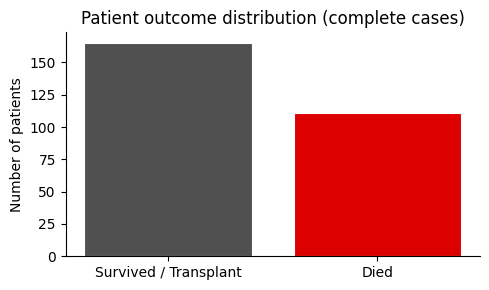

Figure saved.


In [7]:
class_counts = full_df[TARGET_COL].value_counts().sort_index()
class_labels = {0: 'Survived / Transplant', 1: 'Died'}

print('Class distribution in the complete dataset:')
for label, count in class_counts.items():
    pct = count / len(full_df) * 100
    print(f'  {class_labels[label]:<25} (label {label}):  {count} patients  ({pct:.1f}%)')

# Visualise class balance
fig, ax = plt.subplots(figsize=(5, 3))
ax.bar([class_labels[0], class_labels[1]], class_counts.values,
       color=['#505050', '#DC0000'], edgecolor='white', linewidth=0.8)
ax.set_ylabel('Number of patients')
ax.set_title('Patient outcome distribution (complete cases)')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('output/figures/eda_class_distribution.png', dpi=150)
plt.show()
print('Figure saved.')

---

## Section 5: Train and Test Split

We split the 276 complete cases into a 70 percent training set and a 30 percent held-out test set. The split uses stratified sampling on the target variable, which guarantees that the proportion of patients who died is the same in both partitions. Without stratification, a random split could place most of the minority class (died) in one partition by chance, which would distort both training and evaluation.

The random seed is fixed at 42 throughout the paper so that every result is fully reproducible.

In [8]:
train_df, test_df = split_data(full_df, test_size=0.30, random_state=42)

print(f'Training set: {len(train_df)} patients')
print(f'Test set:     {len(test_df)} patients')
print()

train_class = train_df[TARGET_COL].value_counts().sort_index()
test_class  = test_df[TARGET_COL].value_counts().sort_index()

print('Class balance after stratified split:')
print(f'  Training  —  Survived/Transplant: {train_class[0]}  |  Died: {train_class[1]}')
print(f'  Test      —  Survived/Transplant: {test_class[0]}   |  Died: {test_class[1]}')
print()
print(f'  Training mortality rate: {train_class[1] / len(train_df) * 100:.1f}%')
print(f'  Test mortality rate:     {test_class[1] / len(test_df) * 100:.1f}%')

Training set: 193 patients
Test set:     83 patients

Class balance after stratified split:
  Training  —  Survived/Transplant: 115  |  Died: 78
  Test      —  Survived/Transplant: 50   |  Died: 33

  Training mortality rate: 40.4%
  Test mortality rate:     39.8%


---

## Section 6: Fitting the Scaler

The generative models require all feature values to be in the range zero to one. We fit a MinMax scaler on the training set and apply it to normalise data before feeding it to the models. Crucially, the scaler is fitted on the training set only — never on the test set. This prevents any information about test set values from influencing the generation process.

In [9]:
scaler = fit_scaler(train_df)
print('MinMax scaler fitted on training data.')
print('Scale range applied to each feature: 0.0 to 1.0')
print()
print('Feature value ranges learned from training data:')
col_order = ALL_FEATURE_COLS + [TARGET_COL]
for col, lo, hi in zip(col_order, scaler.data_min_, scaler.data_max_):
    print(f'  {col:<15}  min = {lo:.2f}   max = {hi:.2f}')

MinMax scaler fitted on training data.
Scale range applied to each feature: 0.0 to 1.0

Feature value ranges learned from training data:
  N_Days           min = 77.00   max = 4556.00
  Age              min = 9598.00   max = 28650.00
  Bilirubin        min = 0.30   max = 25.50
  Cholesterol      min = 120.00   max = 1775.00
  Albumin          min = 2.53   max = 4.38
  Copper           min = 9.00   max = 588.00
  Alk_Phos         min = 310.00   max = 13862.40
  SGOT             min = 28.38   max = 328.60
  Tryglicerides    min = 33.00   max = 598.00
  Platelets        min = 70.00   max = 563.00
  Prothrombin      min = 9.00   max = 17.10
  Sex              min = 0.00   max = 1.00
  Drug             min = 0.00   max = 1.00
  Ascites          min = 0.00   max = 1.00
  Hepatomegaly     min = 0.00   max = 1.00
  Spiders          min = 0.00   max = 1.00
  Edema            min = 0.00   max = 2.00
  Stage            min = 1.00   max = 4.00
  Status           min = 0.00   max = 1.00


---

## Section 7: Saving All Outputs

All preprocessed data is saved to `output/data/` so that subsequent notebooks can load it directly without re-running the preprocessing steps.

In [10]:
os.makedirs('output/data', exist_ok=True)
os.makedirs('output/figures', exist_ok=True)
os.makedirs('output/results', exist_ok=True)

save_data(full_df,  'complete_data.csv')
save_data(train_df, 'train_real.csv')
save_data(test_df,  'test_real.csv')
save_scaler(scaler)

print()
print('All data preparation outputs saved.')
print('Proceed to Notebook 2 for synthetic data generation.')

Saved complete_data.csv to /Users/michaeludousoro/Desktop/liver_cirrhosis_article/output/data/complete_data.csv
Saved train_real.csv to /Users/michaeludousoro/Desktop/liver_cirrhosis_article/output/data/train_real.csv
Saved test_real.csv to /Users/michaeludousoro/Desktop/liver_cirrhosis_article/output/data/test_real.csv
Scaler saved to /Users/michaeludousoro/Desktop/liver_cirrhosis_article/output/data/scaler.pkl

All data preparation outputs saved.
Proceed to Notebook 2 for synthetic data generation.
